<a href="https://colab.research.google.com/github/aparna-2001/machine_learning_using_python/blob/main/forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

In [3]:
wsb_df = pd.read_csv('wsb.csv')
wsb_df.head(10)

,Month,Sale Quantity,Promotion Expenses,Competition Promotion
0,1,3002666,105,1
1,2,4401553,145,0
2,3,3205279,118,1
3,4,4245349,130,0
4,5,3001940,98,1
5,6,4377766,156,0
6,7,2798343,98,1
7,8,4303668,144,0
8,9,2958185,112,1
9,10,3623386,120,0


In [4]:
wsb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Month                  48 non-null     int64
 1   Sale Quantity          48 non-null     int64
 2   Promotion Expenses     48 non-null     int64
 3   Competition Promotion  48 non-null     int64
dtypes: int64(4)
memory usage: 1.6 KB


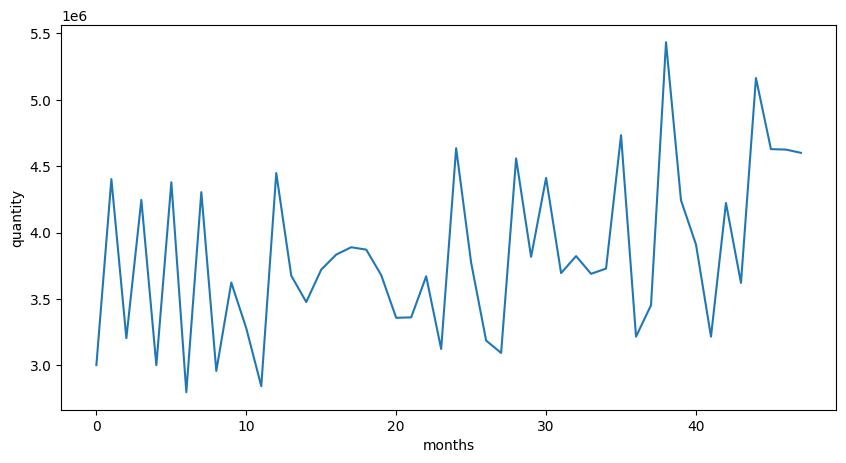

In [5]:

plt.figure(figsize=(10,5))
plt.xlabel('months')
plt.ylabel('quantity')


plt.plot(wsb_df['Sale Quantity'])

*forecasting using moving average*

In [6]:
wsb_df['mv_12'] = wsb_df['Sale Quantity'].rolling(12).mean().shift(1)
wsb_df.head(10)

,Month,Sale Quantity,Promotion Expenses,Competition Promotion,mv_12
0,1,3002666,105,1,NaN
1,2,4401553,145,0,NaN
2,3,3205279,118,1,NaN
3,4,4245349,130,0,NaN
4,5,3001940,98,1,NaN
5,6,4377766,156,0,NaN
6,7,2798343,98,1,NaN
7,8,4303668,144,0,NaN
8,9,2958185,112,1,NaN
9,10,3623386,120,0,NaN


In [7]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
wsb_df[['Sale Quantity', 'mv_12']][36:]

,Sale Quantity,mv_12
36,3216483,3928410.33
37,3453239,3810280.00
38,5431651,3783643.33
39,4241851,3970688.42
40,3909887,4066369.08
41,3216438,4012412.75
42,4222005,3962369.58
43,3621034,3946629.42
44,5162201,3940489.50
45,4627177,4052117.17


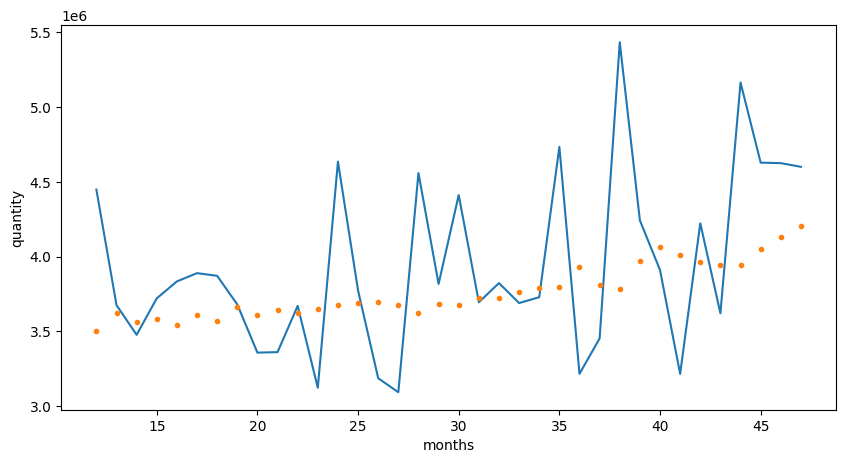

In [8]:
plt.figure(figsize=(10,5))

plt.xlabel('months')
plt.ylabel('quantity')

plt.plot(wsb_df['Sale Quantity'][12:])
plt.plot(wsb_df['mv_12'][12:],'.')

*Forecasting accuracy* (of moving average)

   * MAPE
   * RMSE

*MAPE*

In [9]:
def get_mape(actual, predicted):
   y_true, y_pred = np.array(actual), np.array(predicted)
   return np.round(np.mean(np.abs((actual-predicted)/actual))*100, 2)

In [10]:
get_mape(wsb_df['Sale Quantity'][36:].values, wsb_df['mv_12'][36:].values)

np.float64(14.04)

*RMSE*

In [11]:
np.sqrt(mean_squared_error(wsb_df['Sale Quantity'][36:].values, wsb_df['mv_12'][36:].values))

np.float64(734725.8359239782)

*Exponential smoothing*

In [12]:
wsb_df['ewm'] = wsb_df['Sale Quantity'].ewm(alpha=0.2).mean()
pd.options.display.float_format = '{:.2f}'.format
wsb_df[36:]

,Month,Sale Quantity,Promotion Expenses,Competition Promotion,mv_12,ewm
36,37,3216483,121,1,3928410.33,3828234.64
37,38,3453239,128,0,3810280.00,3753219.93
38,39,5431651,170,0,3783643.33,4088961.93
39,40,4241851,160,0,3970688.42,4119543.81
40,41,3909887,151,1,4066369.08,4077607.99
41,42,3216438,120,1,4012412.75,3905359.34
42,43,4222005,152,0,3962369.58,3968692.78
43,44,3621034,125,0,3946629.42,3899157.24
44,45,5162201,170,0,3940489.50,4151776.99
45,46,4627177,160,0,4052117.17,4246860.31


*Forecasting accuracy* (of exponential smoothing)

   * MAPE
   * RMSE

In [13]:
get_mape(wsb_df['Sale Quantity'][36:].values, wsb_df['ewm'][36:].values)

np.float64(11.15)

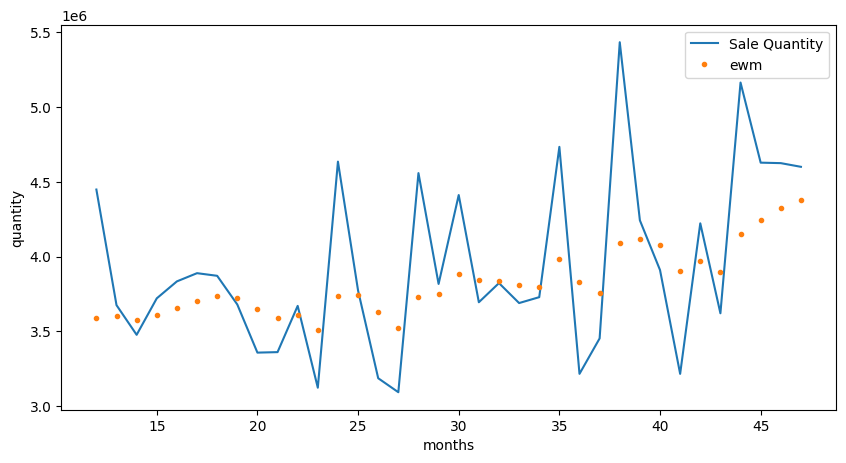

In [14]:
plt.figure(figsize=(10,5))

plt.xlabel('months')
plt.ylabel('quantity')


plt.plot(wsb_df['Sale Quantity'][12:], label = 'Sale Quantity')
plt.plot(wsb_df['ewm'][12:],'.', label = 'ewm')

plt.legend()


*Decomposition*

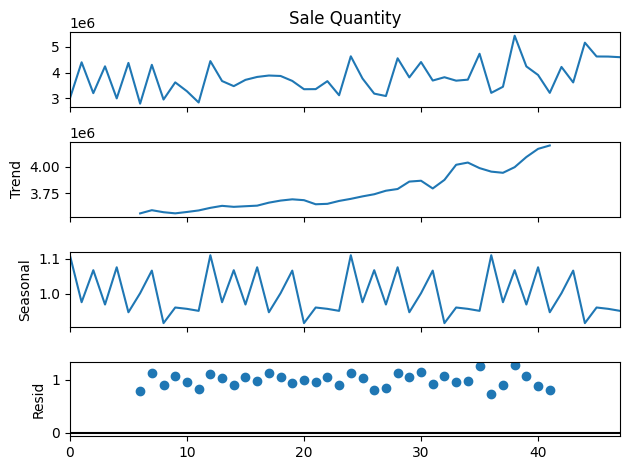

In [15]:
ts_decompose = seasonal_decompose(wsb_df['Sale Quantity'],
                                  model = 'multiplicative',
                                  period = 12)

ts_plot = ts_decompose.plot()
ts_plot.show()

*ARIMA models*

In [16]:
vimana_df = pd.read_csv('vimana.csv')
vimana_df.head(10)

,Month,demand
0,1,457
1,2,439
2,3,404
3,4,392
4,5,403
5,6,371
6,7,382
7,8,358
8,9,594
9,10,482


In [17]:
vimana_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Month   37 non-null     int64
 1   demand  37 non-null     int64
dtypes: int64(2)
memory usage: 724.0 bytes


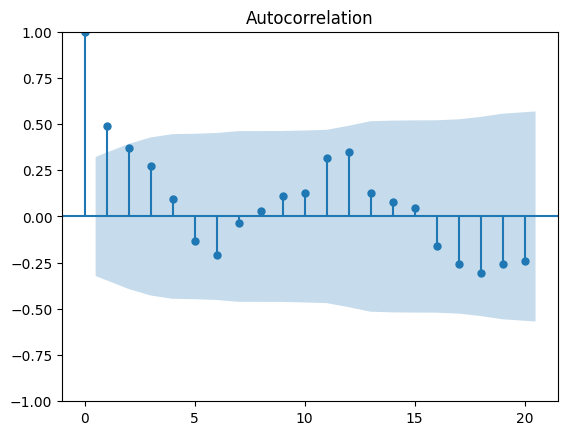

In [18]:
acf_plot = plot_acf(vimana_df['demand'], lags = 20)
acf_plot.show()

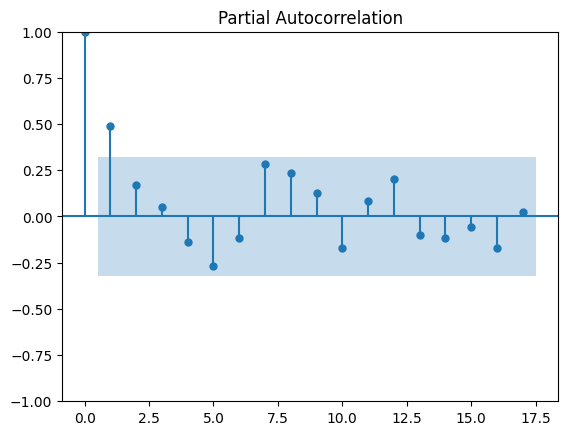

In [19]:
pacf_plot = plot_pacf(vimana_df['demand'], lags = 17)
pacf_plot.show()

*Building AR model*

In [20]:
arima = ARIMA(vimana_df.demand[0:30].astype(np.float64).to_numpy(), order = (1,0,0))
ar_model = arima.fit()

In [21]:
ar_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   30
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -182.765
Date:                Mon, 02 Mar 2026   AIC                            371.530
Time:                        10:08:55   BIC                            375.734
Sample:                             0   HQIC                           372.875
                                 - 30                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        513.4426     43.815     11.718      0.000     427.567     599.318
ar.L1          0.4726      0.181      2.617      0.009       0.119       0.827
sigma2      1.136e+04   3299.003      3.444      0.001    4896.110    1.78e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.55   Jarque-Bera (JB):                 1.72
Prob(Q):                              0.46   Prob(JB):                         0.42
Heteroskedasticity (H):               2.72   Skew:                             0.59
Prob(H) (two-sided):                  0.13   Kurtosis:                         2.96
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

*arima model forecast accuracy*

In [22]:
#mape

forecast_31_37 = ar_model.predict(30,36)
get_mape(vimana_df['demand'][30:], forecast_31_37)

np.float64(19.12)

In [23]:
arima_ma = ARIMA(vimana_df.demand[0:30].astype(np.float64).to_numpy(), order = (0,0,1))
arima_model = arima_ma.fit()
arima_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   30
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -184.297
Date:                Mon, 02 Mar 2026   AIC                            374.595
Time:                        10:08:56   BIC                            378.799
Sample:                             0   HQIC                           375.940
                                 - 30                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        517.0213     31.024     16.665      0.000     456.215     577.827
ma.L1          0.3173      0.224      1.414      0.157      -0.122       0.757
sigma2      1.265e+04   4209.484      3.004      0.003    4395.561    2.09e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.41   Jarque-Bera (JB):                 2.21
Prob(Q):                              0.52   Prob(JB):                         0.33
Heteroskedasticity (H):               2.25   Skew:                             0.66
Prob(H) (two-sided):                  0.22   Kurtosis:                         2.90
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [24]:
forecast_31_37_ma = arima_model.predict(30,36)
get_mape(vimana_df.demand[30:], forecast_31_37_ma)

np.float64(17.78)

*ARMA Model*

In [26]:
arima_both = ARIMA(vimana_df['demand'][0:30].astype(np.float64).to_numpy(), order = (1,0,1))
arima_both_model = arima_both.fit()
arima_both_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   30
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -181.846
Date:                Mon, 02 Mar 2026   AIC                            371.692
Time:                        10:11:33   BIC                            377.296
Sample:                             0   HQIC                           373.485
                                 - 30                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        508.3844     59.146      8.595      0.000     392.460     624.308
ar.L1          0.7421      0.316      2.348      0.019       0.123       1.362
ma.L1         -0.3395      0.539     -0.629      0.529      -1.397       0.718
sigma2      1.065e+04   3040.079      3.505      0.000    4696.417    1.66e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.13   Jarque-Bera (JB):                 2.46
Prob(Q):                              0.72   Prob(JB):                         0.29
Heteroskedasticity (H):               3.07   Skew:                             0.67
Prob(H) (two-sided):                  0.09   Kurtosis:                         3.38
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [27]:
forecast_31_37_both = arima_both_model.predict(30,36)
get_mape(vimana_df.demand[30:], forecast_31_37_both)

np.float64(20.27)

In [29]:
store_df = pd.read_excel('store.xls')
store_df.head(10)

,Date,demand
0,2014-10-01,15
1,2014-10-02,7
2,2014-10-03,8
3,2014-10-04,10
4,2014-10-05,13
5,2014-10-06,5
6,2014-10-07,12
7,2014-10-08,12
8,2014-10-09,13
9,2014-10-10,13


In [30]:
store_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    115 non-null    datetime64[ns]
 1   demand  115 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 1.9 KB


In [31]:
store_df.set_index(pd.to_datetime(store_df.Date), inplace = True)
store_df.drop('Date', axis = 1, inplace = True)
store_df.head(10)

,demand
Date,
2014-10-01,15
2014-10-02,7
2014-10-03,8
2014-10-04,10
2014-10-05,13
2014-10-06,5
2014-10-07,12
2014-10-08,12
2014-10-09,13


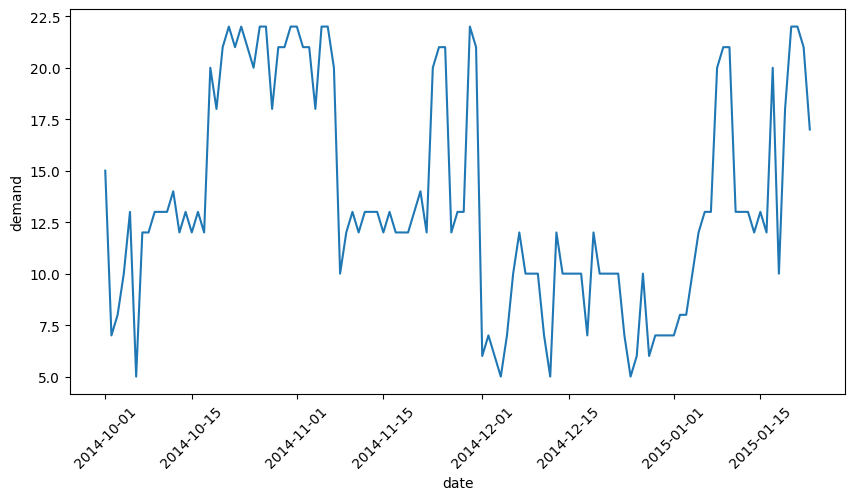

In [37]:
plt.figure(figsize=(10,5))
plt.xlabel('date')
plt.ylabel('demand')
plt.xticks(rotation=45)

plt.plot(store_df.demand)

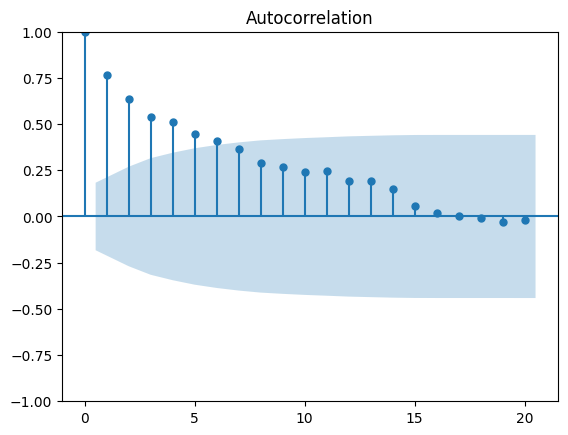

In [40]:
acf_plot_store = plot_acf(store_df.demand, lags = 20)
acf_plot_store.show()

*Dicky Fuller Test*

In [45]:
def adfuller_test(ts):

    adfuller_result = adfuller(ts, autolag= None)
    adfuller_out = pd.Series(adfuller_result[0:4],
                             index = ['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])


    print(adfuller_out)
adfuller_test(store_df.demand)

Test Statistic                 -1.65
p-value                         0.46
#Lags Used                     13.00
Number of Observations Used   101.00
dtype: float64


* The time series is not stationary because p-value is greater than 0.05

In [46]:
store_df['demand_df'] = store_df.demand - store_df.demand.shift(1)
store_df.head(10)

,demand,demand_df
Date,,
2014-10-01,15,NaN
2014-10-02,7,-8.00
2014-10-03,8,1.00
2014-10-04,10,2.00
2014-10-05,13,3.00
2014-10-06,5,-8.00
2014-10-07,12,7.00
2014-10-08,12,0.00
2014-10-09,13,1.00


In [47]:
store_df['demand_df'].dropna()

,demand_df
Date,
2014-10-02,-8.00
2014-10-03,1.00
2014-10-04,2.00
2014-10-05,3.00
2014-10-06,-8.00
...,...
2015-01-19,8.00
2015-01-20,4.00
2015-01-21,0.00


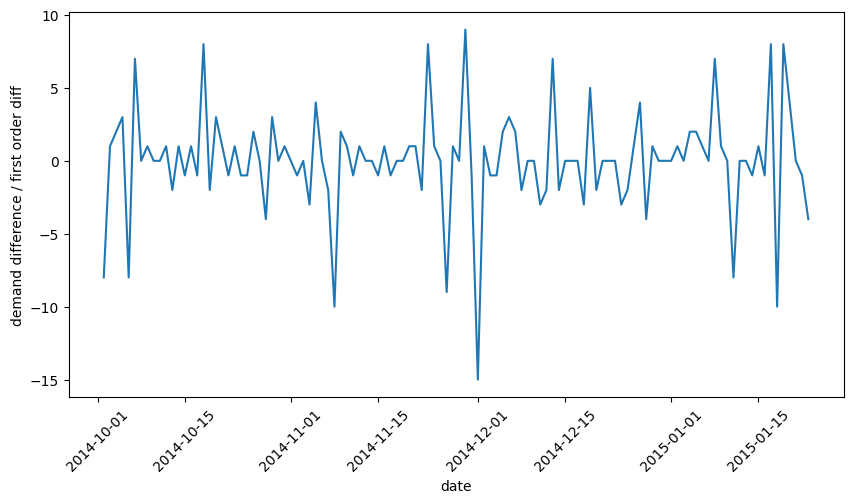

In [52]:

plt.figure(figsize=(10,5))
plt.xlabel('date')
plt.ylabel('demand difference / first order diff')
plt.xticks(rotation = 45)


plt.plot(store_df['demand_df'])

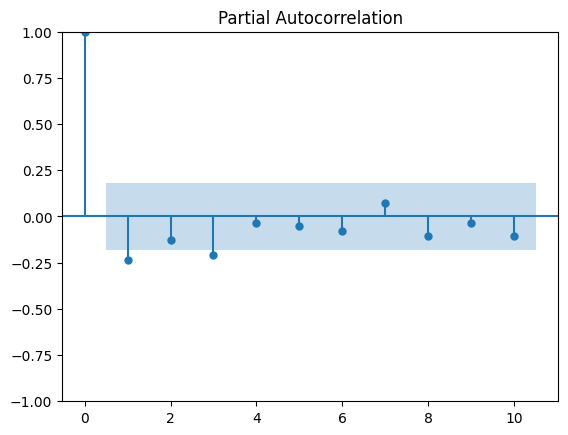

In [54]:
pacf_plot_store_df = plot_pacf(store_df['demand_df'].dropna(), lags = 10)
pacf_plot_store_df.show()

In [55]:
store_train = store_df[0:100]
store_test = store_df[100:]

In [56]:
arima = ARIMA(store_train.demand.astype(np.float64).to_numpy(), order = (1,0,1))
arima_model_new = arima.fit()
arima_model_new.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  100
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -258.351
Date:                Mon, 02 Mar 2026   AIC                            524.702
Time:                        10:39:52   BIC                            535.123
Sample:                             0   HQIC                           528.920
                                - 100                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.4469      1.913      7.029      0.000       9.697      17.197
ar.L1          0.8630      0.075     11.500      0.000       0.716       1.010
ma.L1         -0.2156      0.153     -1.405      0.160      -0.516       0.085
sigma2        10.1668      1.181      8.606      0.000       7.851      12.482
===================================================================================
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):                64.66
Prob(Q):                              0.73   Prob(JB):                         0.00
Heteroskedasticity (H):               0.73   Skew:                            -0.74
Prob(H) (two-sided):                  0.36   Kurtosis:                         6.65
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

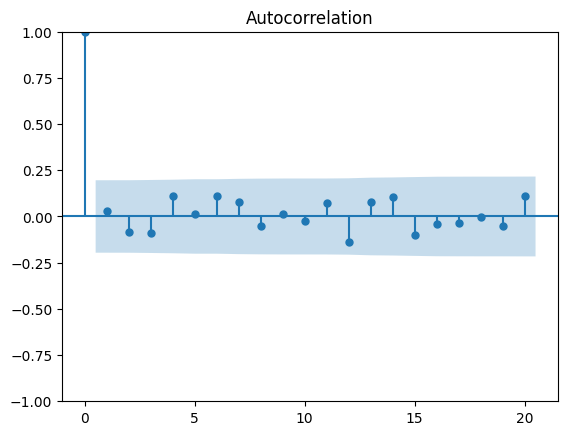

In [57]:
acf_plot_store_new = plot_acf(arima_model_new.resid, lags = 20)

acf_plot_store_new.show()

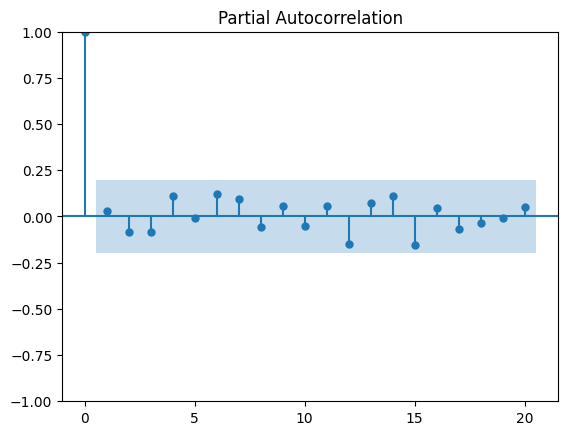

In [58]:
pacf_plot_store_new = plot_pacf(arima_model_new.resid, lags = 20)

In [60]:
store_predict = arima_model_new.forecast(steps = 15)
store_predict

array([17.59720311, 17.02862087, 16.53793225, 16.11446612, 15.74901324,
       15.43362604, 15.16144569, 14.92655302, 14.72383975, 14.54889744,
       14.39792157, 14.26762882, 14.15518568, 14.05814683, 13.97440194])

In [63]:
get_mape(store_df.demand[100:],store_predict)

np.float64(26.04)